In [51]:
import os
import torch
import mlflow
import numpy as np 
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import (
    TrainingArguments, 
    Trainer, 
    DistilBertForSequenceClassification, 
    DistilBertTokenizer, 
    DataCollatorWithPadding, 
    EvalPrediction
)
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Train Model

In [52]:
mlflow.set_tracking_uri("http://172.18.0.161:5012")
mlflow.autolog(log_models=False)   

if not mlflow.get_experiment_by_name(name="Distilbert Fine Tuning"):
    print("Creating model...")
    mlflow.create_experiment(name="Distilbert Fine Tuning", artifact_location="mlflow-artifacts:/distilbert")


distillbert_experiment = mlflow.get_experiment_by_name(name="Distilbert Fine Tuning")

2026/05/16 03:32:21 INFO mlflow.bedrock: Enabled auto-tracing for Bedrock. Note that MLflow can only trace boto3 service clients that are created after this call. If you have already created one, please recreate the client by calling `boto3.client`.
2026/05/16 03:32:21 INFO mlflow.tracking.fluent: Autologging successfully enabled for boto3.
2026/05/16 03:32:21 INFO mlflow.tracking.fluent: Autologging successfully enabled for transformers.


In [53]:
if torch.cuda.is_available():
    print("Running training with on CUDA!")

Running training with on CUDA!


In [54]:
tokenizer = DistilBertTokenizer.from_pretrained("distilbert/distilbert-base-uncased")

In [55]:
def tokenize(batch):
    tokens =  tokenizer(
        batch["text"],
        truncation=True,
        max_length=512,
    )

    tokens['labels'] = batch['label']

    return tokens

dataset_hf = load_dataset("imdb", cache_dir="data/cache")
dataset = dataset_hf.map(tokenize, batched=True)

In [56]:
model = DistilBertForSequenceClassification.from_pretrained("distilbert/distilbert-base-uncased", num_labels=2)

model.config.id2label = {0: "NEGATIVE", 1: "POSITIVE"}
model.config.label2id = {"NEGATIVE": 0, "POSITIVE": 1}

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [57]:
args = TrainingArguments(
    output_dir="models/distilbert/training",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    learning_rate=2e-5,
    eval_strategy="epoch",
    dataloader_pin_memory=False,
    seed=42,
)

In [58]:
def compute_metrics(eval_pred: EvalPrediction):
    predictions, labels = eval_pred

    # Convert logits to predicted class indices
    predictions = np.argmax(predictions, axis=1)

    cm = confusion_matrix(labels, predictions, normalize='true')

    fig, ax = plt.subplots(figsize=(6, 6))
    ConfusionMatrixDisplay(cm).plot(ax=ax, cmap="Blues")
    ax.set_title("Confusion Matrix - Validation")

    with mlflow.active_run():
        mlflow.log_figure(fig, "validation_confusion_matrix.png")

    return {
        'accuracy': accuracy_score(labels, predictions),
        'recall': recall_score(labels, predictions),
        'precision': precision_score(labels, predictions),
        'f1': f1_score(labels, predictions),
    }

In [59]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model, 
    args=args, 
    train_dataset=dataset["train"], 
    eval_dataset=dataset["test"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

/home/loris/Documents/IAI_Project/.venv/lib/python3.13/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
/home/loris/Documents/IAI_Project/.venv/lib/python3.13/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. I

Epoch,Training Loss,Validation Loss,Accuracy,Recall,Precision,F1
1,0.229041,0.214644,0.920040,0.880320,0.956287,0.916733
2,0.154202,0.238520,0.929000,0.916720,0.939802,0.928117
3,0.101777,0.286374,0.931200,0.928640,0.933419,0.931023
4,0.051381,0.341660,0.930960,0.931280,0.930684,0.930982
5,0.036533,0.355981,0.932360,0.935440,0.929713,0.932568


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

🏃 View run rebellious-mole-752 at: http://172.18.0.161:5012/#/experiments/0/runs/dfbe199f6e63416aa3fc7f99926c5903
🧪 View experiment at: http://172.18.0.161:5012/#/experiments/0


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Registered model 'distilbert-finetuned' already exists. Creating a new version of this model...
2026/05/16 03:57:41 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: distilbert-finetuned, version 13
Created version '13' of model 'distilbert-finetuned'.


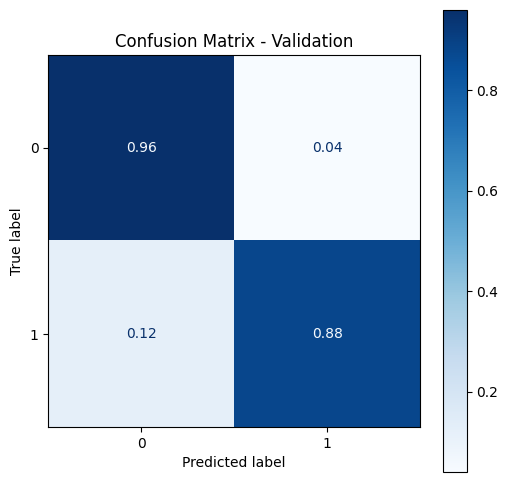

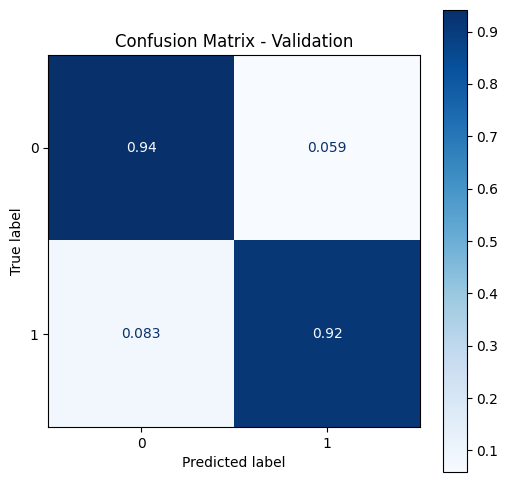

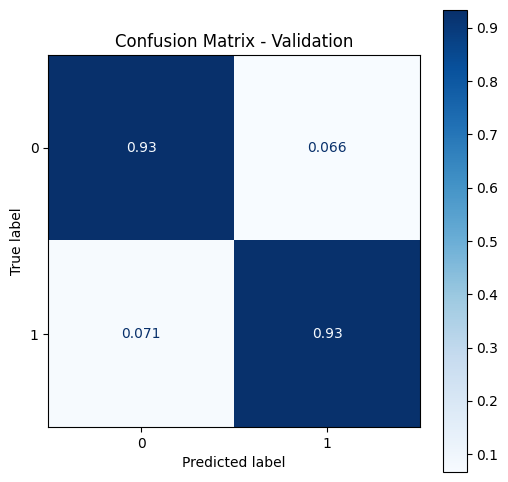

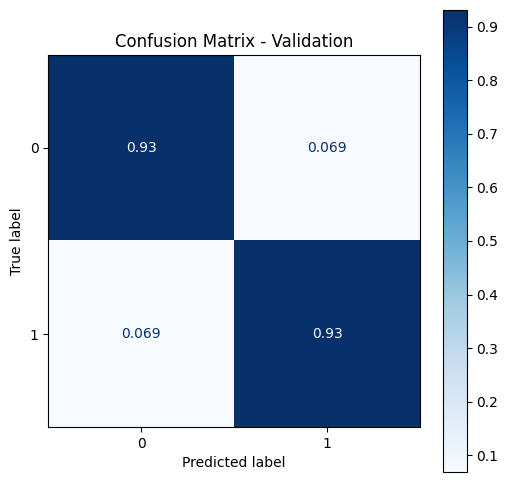

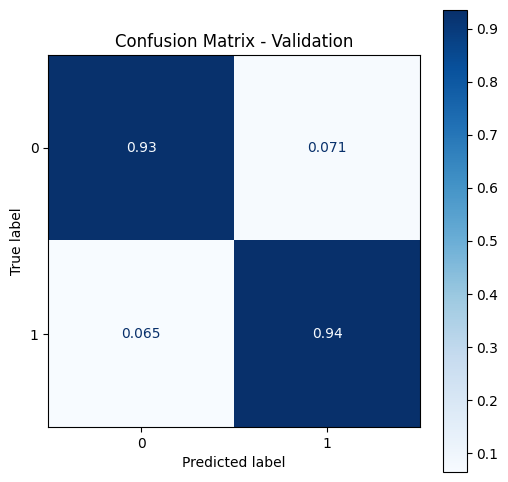

In [60]:
with mlflow.start_run(experiment_id=distillbert_experiment.experiment_id):
    mlflow.log_input(
        mlflow.data.from_huggingface(dataset_hf["train"], name="train"),
        context="training"
    )
    mlflow.log_input(
        mlflow.data.from_huggingface(dataset_hf["test"], name="test"),
        context="validation"
    )

    trainer.train()

    trainer.save_model("models/distilbert/final")

    mlflow.transformers.log_model(
        transformers_model={
            "model": trainer.model,
            "tokenizer": tokenizer
        },
        name="model_distilbert-finetuned",
        registered_model_name="distilbert-finetuned",
        task="text-classification",
        save_pretrained=True
    )